In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/llms-you-cant-please-them-all/sample_submission.csv
/kaggle/input/llms-you-cant-please-them-all/test.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [3]:
train = pd.read_csv("/kaggle/input/llms-you-cant-please-them-all/sample_submission.csv")
train.head()

,id,essay
0,1097671,Plucrarealucrarealucrarealucrarealucrarealucra...
1,1726150,Plucrarealucrarealucrarealucrarealucrarealucra...
2,3211968,Plucrarealucrarealucrarealucrarealucrarealucra...


In [4]:
test = pd.read_csv("/kaggle/input/llms-you-cant-please-them-all/test.csv")
test.head()

,id,topic
0,1097671,Compare and contrast the importance of self-re...
1,1726150,Evaluate the effectiveness of management consu...
2,3211968,Discuss the role of self-reliance in achieving...


In [5]:
combined = pd.concat([train,test])
combined.head()

,id,essay,topic
0,1097671,Plucrarealucrarealucrarealucrarealucrarealucra...,NaN
1,1726150,Plucrarealucrarealucrarealucrarealucrarealucra...,NaN
2,3211968,Plucrarealucrarealucrarealucrarealucrarealucra...,NaN
0,1097671,NaN,Compare and contrast the importance of self-re...
1,1726150,NaN,Evaluate the effectiveness of management consu...


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   essay   3 non-null      object
 2   topic   3 non-null      object
dtypes: int64(1), object(2)
memory usage: 192.0+ bytes


In [7]:
combined.dtypes

id        int64
essay    object
topic    object
dtype: object

In [8]:
combined.shape

(6, 3)

In [9]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,6.0,2.011930e+06,971108.836109,1097671.0,1254790.75,1726150.0,2840513.5,3211968.0


In [10]:
combined.columns

Index(['id', 'essay', 'topic'], dtype='object')

<Axes: >

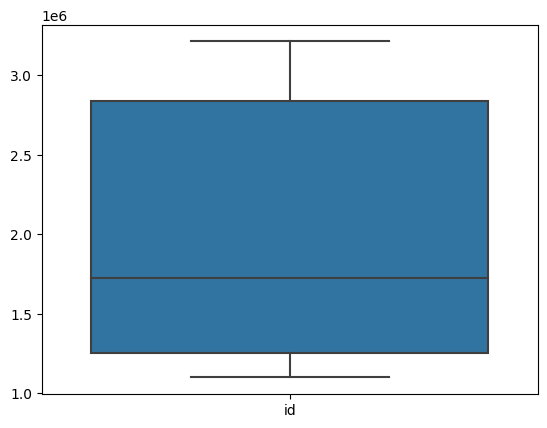

In [11]:
sns.boxplot(combined)

<Axes: >

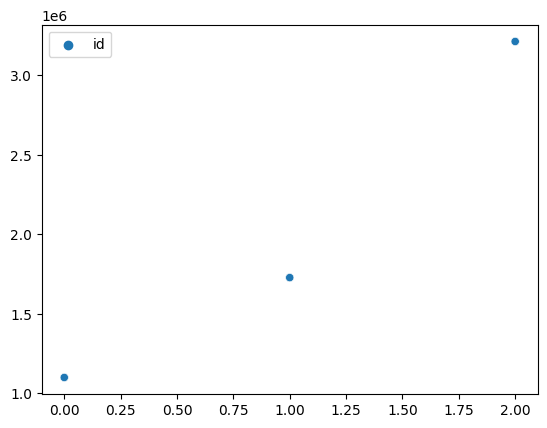

In [12]:
sns.scatterplot(combined)

<Axes: >

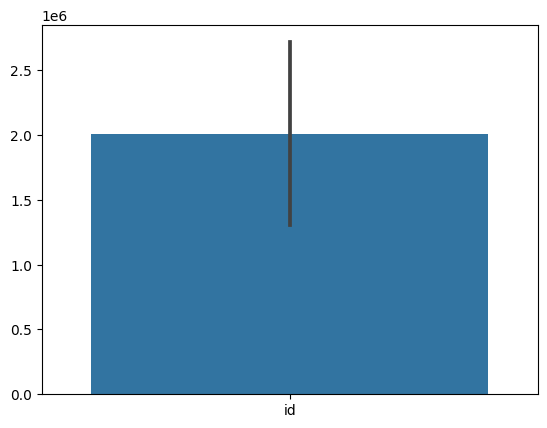

In [13]:
sns.barplot(combined)

<Axes: >

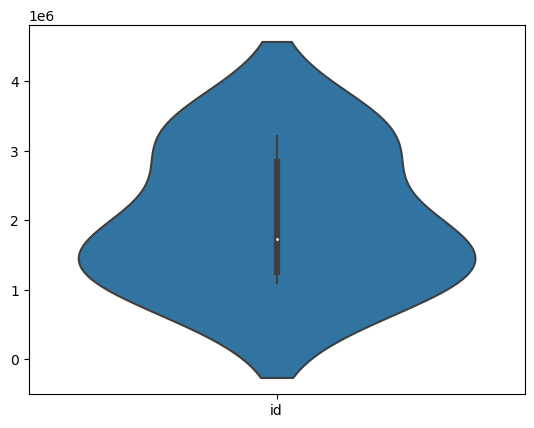

In [14]:
sns.violinplot(combined)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

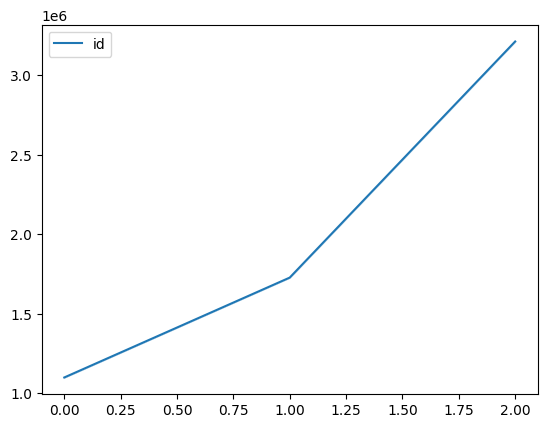

In [15]:
sns.lineplot(combined)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


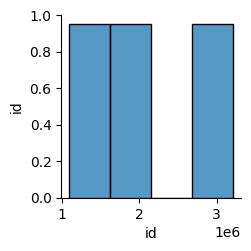

In [16]:
sns.pairplot(combined)

In [17]:
cat_cols = combined.select_dtypes(include='object')

In [18]:
for i in cat_cols:
    (combined[i].value_counts())
    print(i)
    print(''*50)
    

essay

topic



In [19]:
num_cols = combined.select_dtypes(include='number')

In [20]:
for i in num_cols :
    (combined[i].value_counts())
    print(i)
    print(''*50)

id



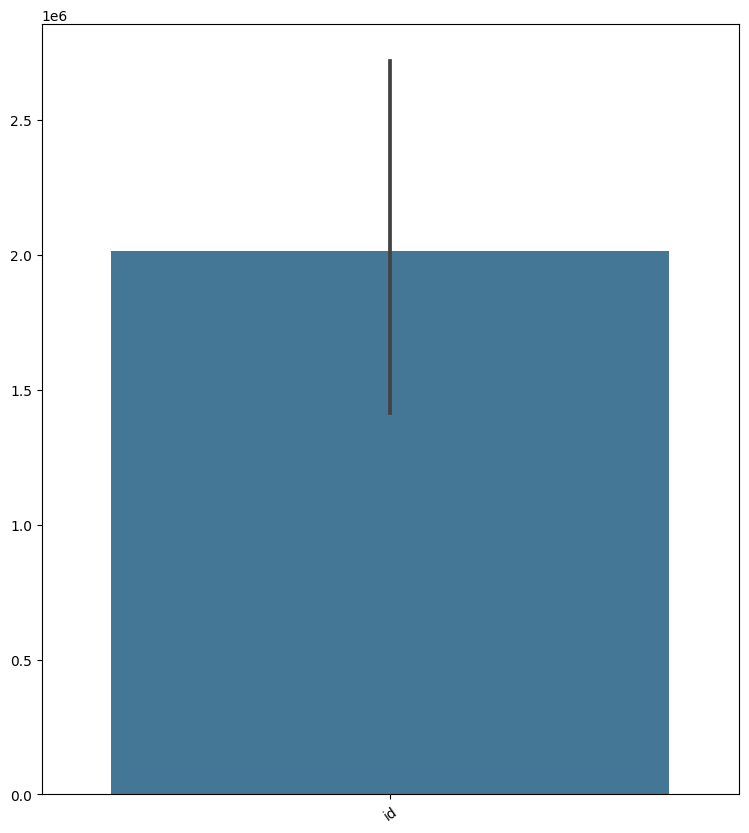

In [21]:
plt.figure(figsize=(9,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=35);
plt.show()

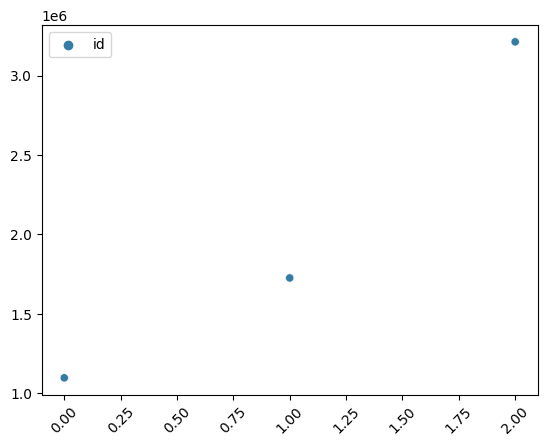

In [22]:
sns.scatterplot(data=combined,palette='mako');
plt.xticks(rotation=45);
plt.show()

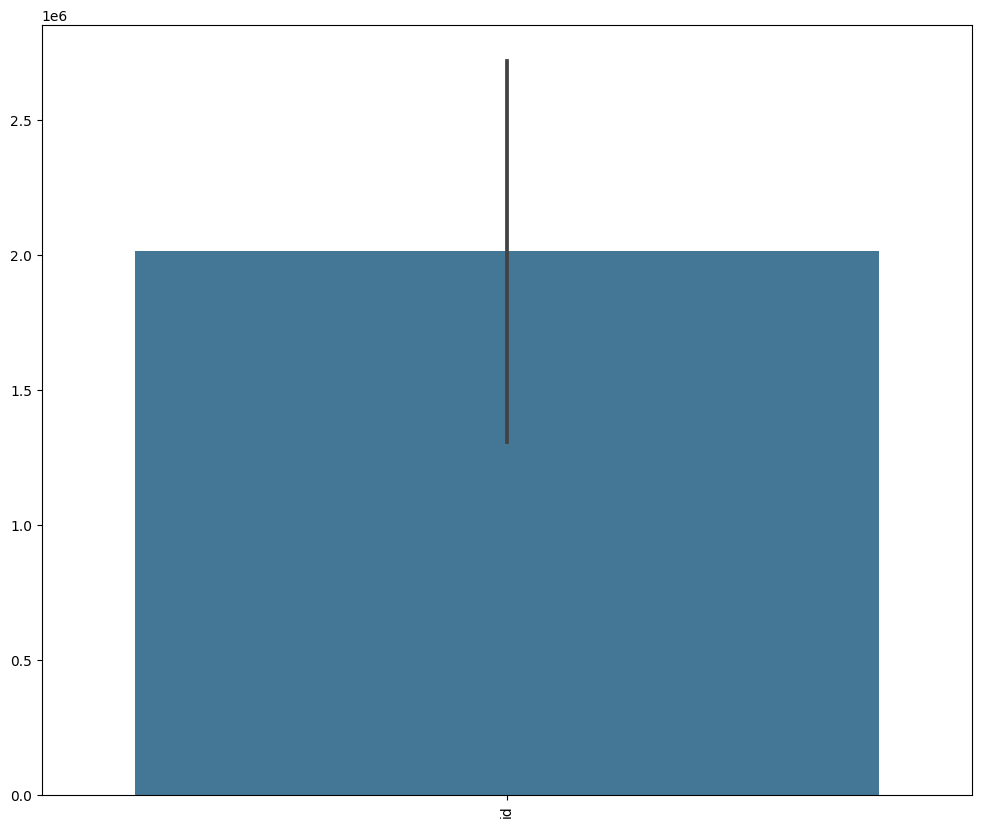

In [23]:
plt.figure(figsize=(12,10))
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=90);
plt.show()

In [24]:
combined.skew

<bound method DataFrame.skew of         id                                              essay  \
0  1097671  Plucrarealucrarealucrarealucrarealucrarealucra...   
1  1726150  Plucrarealucrarealucrarealucrarealucrarealucra...   
2  3211968  Plucrarealucrarealucrarealucrarealucrarealucra...   
0  1097671                                                NaN   
1  1726150                                                NaN   
2  3211968                                                NaN   

                                               topic  
0                                                NaN  
1                                                NaN  
2                                                NaN  
0  Compare and contrast the importance of self-re...  
1  Evaluate the effectiveness of management consu...  
2  Discuss the role of self-reliance in achieving...  >

In [25]:
combined.kurtosis

<bound method DataFrame.kurt of         id                                              essay  \
0  1097671  Plucrarealucrarealucrarealucrarealucrarealucra...   
1  1726150  Plucrarealucrarealucrarealucrarealucrarealucra...   
2  3211968  Plucrarealucrarealucrarealucrarealucrarealucra...   
0  1097671                                                NaN   
1  1726150                                                NaN   
2  3211968                                                NaN   

                                               topic  
0                                                NaN  
1                                                NaN  
2                                                NaN  
0  Compare and contrast the importance of self-re...  
1  Evaluate the effectiveness of management consu...  
2  Discuss the role of self-reliance in achieving...  >

In [26]:
test.head()

,id,topic
0,1097671,Compare and contrast the importance of self-re...
1,1726150,Evaluate the effectiveness of management consu...
2,3211968,Discuss the role of self-reliance in achieving...


In [27]:
combined.tail()

,id,essay,topic
1,1726150,Plucrarealucrarealucrarealucrarealucrarealucra...,NaN
2,3211968,Plucrarealucrarealucrarealucrarealucrarealucra...,NaN
0,1097671,NaN,Compare and contrast the importance of self-re...
1,1726150,NaN,Evaluate the effectiveness of management consu...
2,3211968,NaN,Discuss the role of self-reliance in achieving...


In [28]:
combined.dropna()

,id,essay,topic


In [29]:
combined.merge

<bound method DataFrame.merge of         id                                              essay  \
0  1097671  Plucrarealucrarealucrarealucrarealucrarealucra...   
1  1726150  Plucrarealucrarealucrarealucrarealucrarealucra...   
2  3211968  Plucrarealucrarealucrarealucrarealucrarealucra...   
0  1097671                                                NaN   
1  1726150                                                NaN   
2  3211968                                                NaN   

                                               topic  
0                                                NaN  
1                                                NaN  
2                                                NaN  
0  Compare and contrast the importance of self-re...  
1  Evaluate the effectiveness of management consu...  
2  Discuss the role of self-reliance in achieving...  >

In [30]:
combined.apply

<bound method DataFrame.apply of         id                                              essay  \
0  1097671  Plucrarealucrarealucrarealucrarealucrarealucra...   
1  1726150  Plucrarealucrarealucrarealucrarealucrarealucra...   
2  3211968  Plucrarealucrarealucrarealucrarealucrarealucra...   
0  1097671                                                NaN   
1  1726150                                                NaN   
2  3211968                                                NaN   

                                               topic  
0                                                NaN  
1                                                NaN  
2                                                NaN  
0  Compare and contrast the importance of self-re...  
1  Evaluate the effectiveness of management consu...  
2  Discuss the role of self-reliance in achieving...  >

In [31]:
combined.value_counts()

Series([], Name: count, dtype: int64)

In [32]:
combined.nunique()

id       3
essay    1
topic    3
dtype: int64

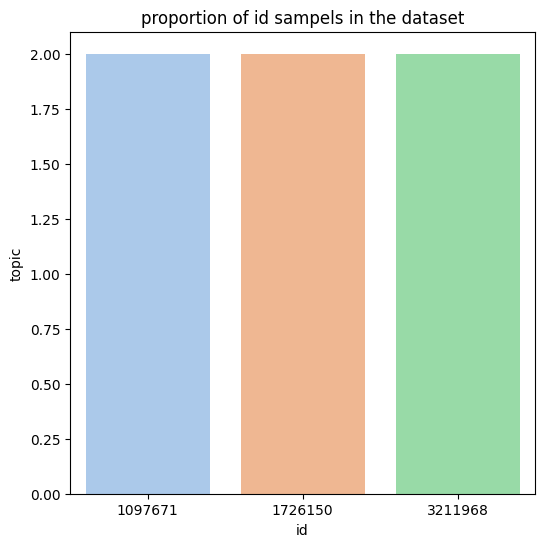

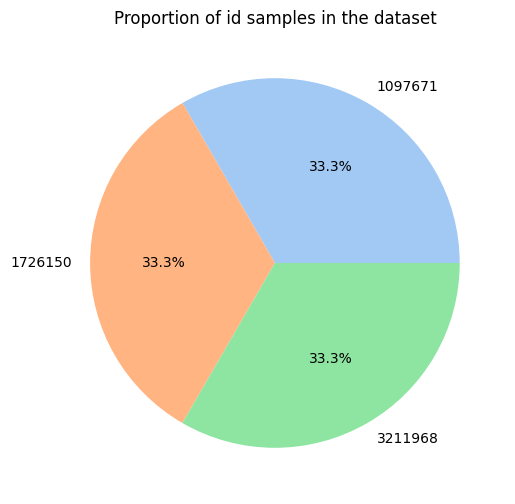

In [33]:
id_count = combined['id'].value_counts()
plt.figure(figsize=(6,6))
sns.barplot(x=id_count.index,y=id_count.values,palette='pastel')
plt.title('proportion of id sampels in the dataset')
plt.xlabel('id')
plt.ylabel('topic')
plt.show()

plt.figure(figsize=(6,6))
plt.pie(id_count, labels=id_count.index, autopct='%1.1f%%', colors=sns.color_palette("pastel"))

plt.title('Proportion of id samples in the dataset')
plt.show()

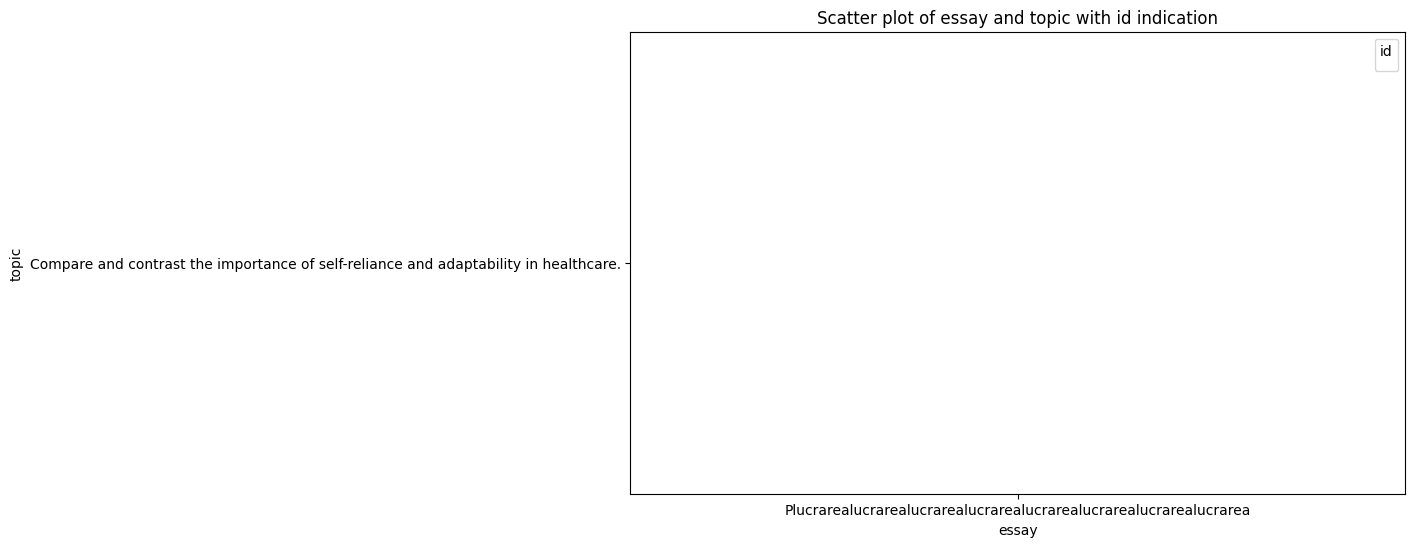

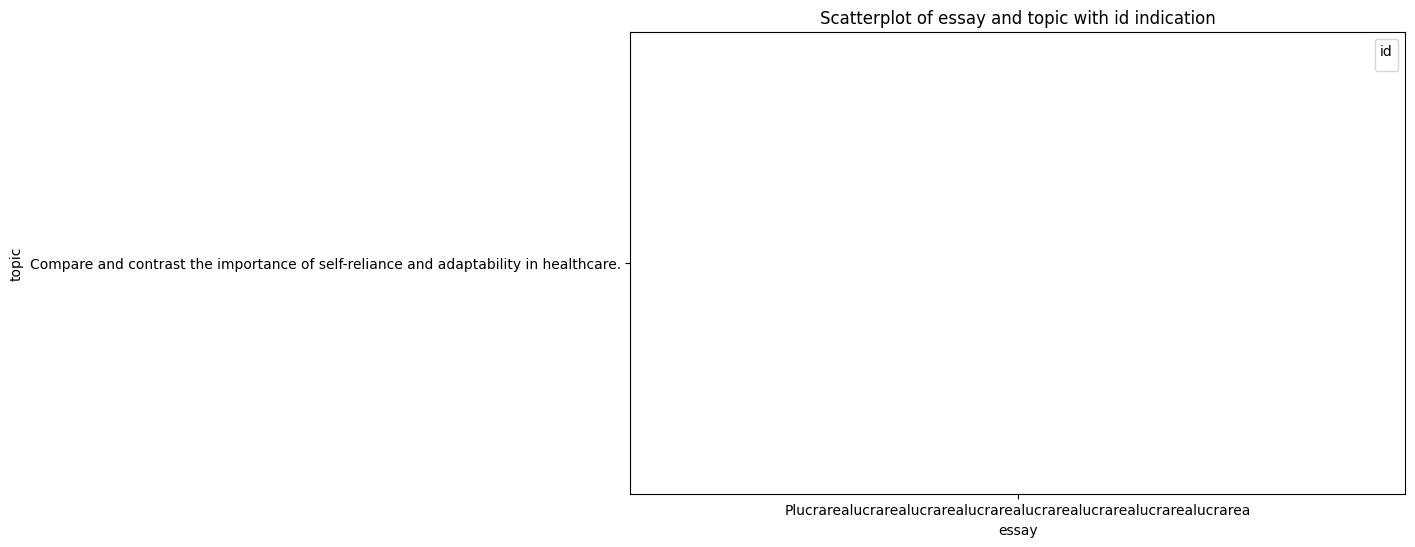

In [34]:
plt.figure(figsize=(10,6))

sns.scatterplot(x='essay', y='topic', hue='id', data=combined, palette='coolwarm',alpha=0.7)

plt.title('Scatter plot of essay and topic with id indication')
plt.xlabel('essay')
plt.ylabel('topic')

plt.legend(title='id',loc='upper right')

plt.show()

plt.figure(figsize=(10,6))

sns.scatterplot(x='essay',y='topic',hue='id',data=combined,palette='coolwarm',alpha=0.7)

plt.title('Scatterplot of essay and topic with id indication')
plt.xlabel('essay')
plt.ylabel('topic')

plt.legend(title='id',loc='upper right')

plt.show()